# LangGraph MCP PowerPoint 튜토리얼

이 튜토리얼에서는 LangGraph와 MCP(Model Context Protocol)를 활용하여 **PowerPoint 프레젠테이션**을 자동으로 생성하고 편집하는 AI 에이전트를 구축합니다. `office-powerpoint-mcp-server`는 `python-pptx` 기반의 MCP 서버로, 34가지 이상의 도구를 통해 슬라이드 생성, 텍스트 관리, 디자인 적용 등 다양한 PowerPoint 작업을 수행할 수 있습니다.

> 참고 자료: [office-powerpoint-mcp-server (PyPI)](https://pypi.org/project/office-powerpoint-mcp-server/) | [GitHub](https://github.com/GongRzhe/Office-PowerPoint-MCP-Server)

### office-powerpoint-mcp-server 주요 도구

| 카테고리 | 주요 도구 | 설명 |
|----------|-----------|------|
| 프레젠테이션 관리 | `create_presentation` | 새 프레젠테이션 파일 생성 |
| 프레젠테이션 관리 | `open_presentation` | 기존 프레젠테이션 열기 |
| 프레젠테이션 관리 | `save_presentation` | 프레젠테이션 저장 |
| 콘텐츠 관리 | `add_slide` | 슬라이드 추가 |
| 콘텐츠 관리 | `manage_text` | 텍스트 추가/편집/서식 |
| 콘텐츠 관리 | `manage_bullets` | 글머리 기호 목록 관리 |
| 템플릿 작업 | `list_templates` | 사용 가능한 템플릿 목록 조회 |
| 템플릿 작업 | `auto_generate_presentation` | 주제 기반 자동 프레젠테이션 생성 |
| 구조 요소 | `add_table` | 표 추가 |
| 구조 요소 | `add_chart` | 차트 추가 |
| 전문 디자인 | `manage_design` | 전체 디자인 관리 |
| 특수 기능 | `add_hyperlink` | 하이퍼링크 추가 |

### 사전 준비

- `uv` 패키지 매니저가 설치되어 있어야 합니다 (`uvx` 명령어 사용)
- API 키 불필요 — 서버가 로컬에서 실행됩니다

```bash
# uvx 사용 가능 여부 확인
uvx --version
```

> **중요**: `office-powerpoint-mcp-server`는 프레젠테이션 상태를 **메모리**에 유지합니다. 에이전트 호출(`astream_graph`) 간에 서버 메모리가 초기화될 수 있으므로, 각 작업에서 반드시 `create_presentation` 또는 `open_presentation`으로 파일을 불러온 뒤 수정하고 `save_presentation`으로 저장하는 패턴을 사용합니다.

## 환경 설정

튜토리얼을 시작하기 전에 필요한 환경을 설정합니다. `dotenv`를 사용하여 API 키를 로드하고, `langchain_teddynote`의 로깅 설정을 활성화하여 LangSmith에서 실행 결과를 확인할 수 있도록 합니다.

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

# 환경 변수 로드
load_dotenv(override=True)
# 프로젝트 추적 프로젝트 이름 설정
logging.langsmith("LangGraph-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-V1-Tutorial


## 라이브러리 임포트 및 MCP 클라이언트 설정

LangGraph 에이전트 구성에 필요한 라이브러리를 임포트하고, MCP 클라이언트 설정을 위한 유틸리티 함수를 정의합니다.

In [2]:
import nest_asyncio
from typing import List, Dict, Any

from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# MCP 클라이언트: 여러 MCP 서버에 연결하여 도구를 가져옵니다
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_mcp_adapters.tools import load_mcp_tools

# 비동기 호환성 활성화 (Jupyter 환경에서 필요)
nest_asyncio.apply()

In [3]:
import sys, os

# Windows + Jupyter workaround: MCP stdio passes Jupyter's sys.stderr to subprocess.Popen,
# but Jupyter's stderr doesn't support fileno(). Patch the default errlog to os.devnull.
if sys.platform == "win32":
    import mcp.client.stdio as _mcp_stdio

    _devnull_file = open(os.devnull, "w")

    # @asynccontextmanager wraps the original function — patch __wrapped__.__defaults__
    if hasattr(_mcp_stdio.stdio_client, "__wrapped__"):
        _mcp_stdio.stdio_client.__wrapped__.__defaults__ = (_devnull_file,)

    # Also patch the helper that creates the subprocess
    _mcp_stdio._create_platform_compatible_process.__defaults__ = (
        None,
        _devnull_file,
        None,
    )


async def setup_mcp_client(server_configs: dict):
    """MCP 클라이언트를 설정하고 도구를 가져옵니다.

    Args:
        server_configs: 서버 구성 딕셔너리. 각 서버의 이름을 키로,
                       연결 정보(command, args, transport 또는 url)를 값으로 가집니다.

    Returns:
        tuple: (MCP 클라이언트, 로드된 도구 목록)
    """
    # MCP 클라이언트 생성
    client = MultiServerMCPClient(server_configs)

    # 서버에 연결하여 도구 목록을 가져옵니다
    tools = await client.get_tools()

    # 로드된 도구 목록을 출력합니다
    print(f"[MCP] {len(tools)}개의 도구가 로드되었습니다:")
    for tool in tools:
        print(f"  - {tool.name}")

    return client, tools

---

## Part 1: 작업 디렉토리 및 MCP 서버 설정

에이전트가 생성하는 `.pptx` 파일이 저장될 작업 디렉토리를 준비합니다. 이후 `uvx`를 통해 `office-powerpoint-mcp-server`를 자동으로 다운로드하고 실행합니다.

> **참고**: `uvx`는 별도 설치 없이 PyPI 패키지를 임시로 실행합니다. 최초 실행 시 패키지를 다운로드하므로 잠시 시간이 걸릴 수 있습니다.

In [4]:
import os

# 생성된 pptx 파일이 저장될 작업 디렉토리를 지정합니다
WORKSPACE_DIR = os.path.abspath("./ppt_workspace")

# 작업 디렉토리가 없으면 생성합니다
os.makedirs(WORKSPACE_DIR, exist_ok=True)

print(f"작업 디렉토리: {WORKSPACE_DIR}")

작업 디렉토리: d:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\ppt_workspace


아래 코드는 `office-powerpoint-mcp-server`를 `uvx`를 통해 stdio 방식으로 실행하고, 사용 가능한 도구 목록을 로드합니다.

In [5]:
# PowerPoint MCP 서버 설정 (uvx를 통한 stdio 전송 방식)
server_configs = {
    "powerpoint": {
        "command": "uvx",
        "args": ["--from", "office-powerpoint-mcp-server", "ppt_mcp_server"],
        "transport": "stdio",
    },
}

# MCP 클라이언트 생성 및 도구 로드
client, tools = await setup_mcp_client(server_configs)

[MCP] 37개의 도구가 로드되었습니다:
  - create_presentation
  - create_presentation_from_template
  - open_presentation
  - save_presentation
  - get_presentation_info
  - get_template_file_info
  - set_core_properties
  - add_slide
  - get_slide_info
  - extract_slide_text
  - extract_presentation_text
  - populate_placeholder
  - add_bullet_points
  - manage_text
  - manage_image
  - add_table
  - format_table_cell
  - add_shape
  - add_chart
  - apply_professional_design
  - apply_picture_effects
  - manage_fonts
  - list_slide_templates
  - apply_slide_template
  - create_slide_from_template
  - create_presentation_from_templates
  - get_template_info
  - auto_generate_presentation
  - optimize_slide_text
  - manage_hyperlinks
  - update_chart_data
  - add_connector
  - manage_slide_masters
  - manage_slide_transitions
  - list_presentations
  - switch_presentation
  - get_server_info


---

## Part 2: PowerPoint 에이전트 생성

MCP PowerPoint 도구를 사용하는 에이전트를 생성합니다. `create_agent`는 LangChain v1에서 제공하는 에이전트 생성 함수로, LLM과 도구를 결합하여 추론-행동 루프를 자동으로 구성합니다.

> 참고: LangGraph v1에서 기존의 `create_react_agent`는 deprecated 되었으며, `langchain.agents.create_agent`를 사용하는 것이 권장됩니다.

In [6]:
# LLM 설정
# 에이전트는 MCP 연결을 유지하기 위해 각 astream_graph 호출 시 async with 블록 안에서 생성됩니다
llm = init_chat_model("claude-sonnet-4-6", temperature=0)

In [7]:
# 스트리밍 출력 함수와 UUID 생성 함수를 import합니다
from langchain_teddynote.messages import astream_graph, random_uuid
from langchain_core.runnables import RunnableConfig

---

## Part 3: 타이틀 슬라이드가 포함된 프레젠테이션 생성

새 프레젠테이션을 만들고 타이틀 슬라이드를 추가한 뒤 저장하는 작업을 **하나의 에이전트 호출**로 처리합니다.

> **패턴**: `create_presentation` → 콘텐츠 추가 → `save_presentation`을 단일 요청에서 완결합니다. 서버가 메모리 상태를 에이전트 호출 간에 유지하지 않을 수 있으므로, 항상 **열기(또는 생성) → 수정 → 저장**을 한 번의 호출 안에서 완료해야 합니다.

In [8]:
# 대화 스레드 ID를 생성합니다
config = RunnableConfig(configurable={"thread_id": random_uuid()})

PPT_PATH = f"{WORKSPACE_DIR}/presentation.pptx"

# client.session() 컨텍스트 안에서 MCP 연결을 유지하며 에이전트를 실행합니다
# → 동일한 서버 프로세스 내에서 모든 도구 호출이 이루어지므로 프레젠테이션 상태가 유지됩니다
client = MultiServerMCPClient(server_configs)
async with client.session("powerpoint") as session:
    tools = await load_mcp_tools(session)
    agent = create_agent(llm, tools, checkpointer=InMemorySaver())

    # 에이전트 실행: 프레젠테이션 생성 + 타이틀 슬라이드 추가 + 저장을 한 번에
    response = await astream_graph(
        agent,
        inputs={
            "messages": [
                (
                    "human",
                    f"다음 순서로 작업해주세요:\n"
                    f"1. '{PPT_PATH}' 경로에 새 프레젠테이션을 생성합니다.\n"
                    f"2. 타이틀 슬라이드를 추가합니다:\n"
                    f"   - 제목: LangGraph로 구축하는 AI 에이전트\n"
                    f"   - 부제목: MCP를 활용한 지능형 워크플로우 구축 가이드\n"
                    f"3. 파일을 '{PPT_PATH}'에 저장합니다.",
                )
            ]
        },
        config=config,
    )


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
순서대로 작업을 진행하겠습니다! 먼저 새 프레젠테이션을 생성하겠습니다.

**Step 1: 새 프레젠테이션 생성**
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "presentation_id": "main_ppt",
  "message": "Created new presentation with ID: main_ppt",
  "slide_count": 0
}
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
프레젠테이션이 생성되었습니다! 이제 타이틀 슬라이드를 추가하겠습니다.

**Step 2: 타이틀 슬라이드 추가**
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "message": "Created slide 0 using template 'title_slide'",
  "slide_index": 0,
  "template_applied": {
    "success": true,
    "template_id": "title_slide",
    "template_name": "Dynamic Title Slide",
    "color_scheme": "modern_blue",
    "elements_created": [
      {
        "type": "text",
        "role": "title",
        "error": "unsupported operand type(s) for 'in': 'bool' and 'EnumType'"
      },
      {
        "type": "text",
        "role": "subtitle",
        "error"

---

## Part 4: 콘텐츠 슬라이드 추가

저장된 프레젠테이션을 열어서 글머리 기호 목록이 포함된 콘텐츠 슬라이드 2개를 추가합니다.

> **패턴**: 별도 에이전트 호출에서 기존 파일을 수정할 때는 반드시 `open_presentation`으로 파일을 먼저 열어야 합니다.

In [9]:
# 새로운 대화 스레드 생성
config = RunnableConfig(configurable={"thread_id": random_uuid()})

client = MultiServerMCPClient(server_configs)
async with client.session("powerpoint") as session:
    tools = await load_mcp_tools(session)
    agent = create_agent(llm, tools, checkpointer=InMemorySaver())

    # 에이전트 실행: 파일 열기 → 콘텐츠 슬라이드 2개 추가 → 저장
    response = await astream_graph(
        agent,
        inputs={
            "messages": [
                (
                    "human",
                    f"다음 순서로 작업해주세요:\n"
                    f"1. '{PPT_PATH}' 파일을 엽니다.\n"
                    f"2. 아래 두 슬라이드를 순서대로 추가합니다:\n\n"
                    f"   [슬라이드 2] 제목: LangGraph란?\n"
                    f"   내용 (글머리 기호):\n"
                    f"   • LangGraph는 LangChain 기반의 멀티 에이전트 프레임워크입니다\n"
                    f"   • StateGraph를 사용하여 복잡한 워크플로우를 그래프로 표현합니다\n"
                    f"   • 노드(Node)와 엣지(Edge)로 에이전트의 행동을 정의합니다\n"
                    f"   • 체크포인팅을 통해 대화 상태를 영속적으로 관리합니다\n\n"
                    f"   [슬라이드 3] 제목: MCP(Model Context Protocol)의 장점\n"
                    f"   내용 (글머리 기호):\n"
                    f"   • 표준화된 도구 인터페이스로 다양한 서비스 연동 가능\n"
                    f"   • stdio 및 HTTP 전송 방식 지원\n"
                    f"   • 동적 도구 탐색으로 확장성 극대화\n"
                    f"   • 파일시스템, 이메일, PowerPoint 등 다양한 도메인 지원\n\n"
                    f"3. 파일을 '{PPT_PATH}'에 저장합니다.",
                )
            ]
        },
        config=config,
    )


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
순서대로 작업을 진행하겠습니다! 먼저 파일을 열겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "presentation_id": "presentation_1",
  "message": "Opened presentation from d:\\2026_Agent\\Teddy_langgraph\\langgraph-v1-tutorial\\06-MCP\\ppt_workspace/presentation.pptx with ID: presentation_1",
  "slide_count": 1
}
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
파일이 열렸습니다. 현재 슬라이드 1개가 있습니다. 이제 슬라이드 2와 슬라이드 3을 동시에 추가하겠습니다!
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "message": "Added slide 1 with layout 1",
  "slide_index": 1,
  "layout_name": "Title and Content"
}{
  "message": "Added slide 2 with layout 1",
  "slide_index": 2,
  "layout_name": "Title and Content"
}
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
슬라이드가 추가되었습니다. 이제 각 슬라이드에 제목과 글머리 기호 내용을 동시에 입력하겠습니다!
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "message": "Po

---

## Part 5: 텍스트 서식 적용

저장된 프레젠테이션을 다시 열어서 타이틀 슬라이드의 제목 텍스트에 폰트 크기, 굵기, 색상 서식을 적용합니다.

In [10]:
# 새로운 대화 스레드 생성
config = RunnableConfig(configurable={"thread_id": random_uuid()})

client = MultiServerMCPClient(server_configs)
async with client.session("powerpoint") as session:
    tools = await load_mcp_tools(session)
    agent = create_agent(llm, tools, checkpointer=InMemorySaver())

    # 에이전트 실행: 파일 열기 → 텍스트 서식 변경 → 저장
    response = await astream_graph(
        agent,
        inputs={
            "messages": [
                (
                    "human",
                    f"다음 순서로 작업해주세요:\n"
                    f"1. '{PPT_PATH}' 파일을 엽니다.\n"
                    f"2. 첫 번째 슬라이드(타이틀 슬라이드)의 제목 텍스트 서식을 변경합니다:\n"
                    f"   - 폰트 크기: 40pt\n"
                    f"   - 굵게(Bold) 설정\n"
                    f"   - 색상: 진한 파란색 (RGB: 0, 70, 127)\n"
                    f"3. 파일을 '{PPT_PATH}'에 저장합니다.",
                )
            ]
        },
        config=config,
    )


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네, 순서대로 작업을 진행하겠습니다. 먼저 파일을 열겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "presentation_id": "presentation_1",
  "message": "Opened presentation from d:\\2026_Agent\\Teddy_langgraph\\langgraph-v1-tutorial\\06-MCP\\ppt_workspace/presentation.pptx with ID: presentation_1",
  "slide_count": 3
}
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
파일을 열었습니다. 이제 첫 번째 슬라이드의 정보를 확인하겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "error": "No presentation is currently loaded or the specified ID is invalid"
}
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "slide_index": 0,
  "layout_name": "Title and Content",
  "placeholder_count": 2,
  "placeholders": [
    {
      "idx": 0,
      "type": "TITLE (1)",
      "name": "Title 1"
    },
    {
      "idx": 1,
      "t

---

## Part 6: 표(Table) 슬라이드 생성

`add_table` 도구를 사용하여 프레임워크 비교표가 담긴 새 프레젠테이션을 생성합니다.

In [11]:
# 새로운 대화 스레드 생성
config2 = RunnableConfig(configurable={"thread_id": random_uuid()})

PPT_PATH2 = f"{WORKSPACE_DIR}/comparison.pptx"

client = MultiServerMCPClient(server_configs)
async with client.session("powerpoint") as session:
    tools = await load_mcp_tools(session)
    agent = create_agent(llm, tools, checkpointer=InMemorySaver())

    # 에이전트 실행: 새 프레젠테이션 생성 → 표 슬라이드 추가 → 저장
    response = await astream_graph(
        agent,
        inputs={
            "messages": [
                (
                    "human",
                    f"다음 순서로 작업해주세요:\n"
                    f"1. '{PPT_PATH2}' 경로에 새 프레젠테이션을 생성합니다.\n"
                    f"2. 아래 비교표가 포함된 슬라이드를 추가합니다:\n"
                    f"   제목: LangGraph vs 기존 에이전트 프레임워크 비교\n\n"
                    f"   표 내용 (4행 4열, 헤더 포함):\n"
                    f"   | 항목           | LangGraph | AutoGen  | CrewAI   |\n"
                    f"   | 멀티 에이전트  | ✓ 지원    | ✓ 지원   | ✓ 지원   |\n"
                    f"   | 그래프 기반    | ✓ 지원    | ✗ 미지원 | ✗ 미지원 |\n"
                    f"   | 체크포인팅     | ✓ 내장    | ✗ 미지원 | ✗ 미지원 |\n\n"
                    f"3. 파일을 '{PPT_PATH2}'에 저장합니다.",
                )
            ]
        },
        config=config2,
    )


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
순서대로 작업을 진행하겠습니다!

## 1단계: 새 프레젠테이션 생성
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "presentation_id": "comparison",
  "message": "Created new presentation with ID: comparison",
  "slide_count": 0
}
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
## 2단계: 비교표가 포함된 슬라이드 추가
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "message": "Added slide 0 with layout 1",
  "slide_index": 0,
  "layout_name": "Title and Content"
}
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
슬라이드가 추가되었습니다. 이제 비교표를 삽입합니다!
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "message": "Added 4x4 table to slide 0",
  "shape_index": 2,
  "rows": 4,
  "cols": 4
}
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
표가 추가되었습니다! 이제 셀 서식을 다듬겠습니다 — 헤더 행 텍스트를 흰색·굵게, LangGraph 열(✓)은 초록, 미지원(✗)은 빨간색으로 강조합니다.
🔄 Node: tools 🔄
- - - - - - - - 

---

## Part 7: 복합 작업 — 완성형 프레젠테이션 자동 생성

여러 도구를 조합하여 5슬라이드짜리 완성형 프레젠테이션을 자동으로 생성합니다. 프레젠테이션 생성부터 모든 슬라이드 작성, 저장까지 **하나의 에이전트 호출**로 처리합니다.

In [12]:
# 새로운 대화 스레드 생성
config3 = RunnableConfig(configurable={"thread_id": random_uuid()})

PPT_PATH3 = f"{WORKSPACE_DIR}/langgraph_intro.pptx"

client = MultiServerMCPClient(server_configs)
async with client.session("powerpoint") as session:
    tools = await load_mcp_tools(session)
    agent = create_agent(llm, tools, checkpointer=InMemorySaver())

    # 에이전트 실행: 완성형 5슬라이드 프레젠테이션 생성 → 저장
    response = await astream_graph(
        agent,
        inputs={
            "messages": [
                (
                    "human",
                    f"다음 순서로 작업해주세요:\n"
                    f"1. '{PPT_PATH3}' 경로에 새 프레젠테이션을 생성합니다.\n"
                    f"2. 아래 5개의 슬라이드를 순서대로 추가합니다:\n\n"
                    f"   [슬라이드 1] 타이틀 슬라이드\n"
                    f"   - 제목: LangGraph V1 완전 정복\n"
                    f"   - 부제목: 멀티 에이전트 시스템 구축 가이드\n\n"
                    f"   [슬라이드 2] 목차\n"
                    f"   - 제목: 목차\n"
                    f"   - 내용: 1. LangGraph 소개 / 2. 핵심 기능 / 3. 활용 사례 / 4. 정리 및 다음 단계\n\n"
                    f"   [슬라이드 3] 핵심 기능\n"
                    f"   - 제목: LangGraph 핵심 기능\n"
                    f"   - 내용 (글머리 기호): StateGraph로 워크플로우 정의 / "
                    f"ToolNode로 도구 실행 자동화 / 체크포인팅으로 상태 영속 관리 / "
                    f"Human-in-the-Loop으로 인간 개입 지원\n\n"
                    f"   [슬라이드 4] 활용 사례\n"
                    f"   - 제목: LangGraph 활용 사례\n"
                    f"   - 내용 (글머리 기호): 고객 지원 자동화 봇 / AI 리서치 에이전트 / "
                    f"코드 리뷰 자동화 시스템 / 데이터 분석 파이프라인\n\n"
                    f"   [슬라이드 5] 마무리\n"
                    f"   - 제목: 정리 및 다음 단계\n"
                    f"   - 내용 (글머리 기호): LangGraph는 강력한 멀티 에이전트 프레임워크 / "
                    f"MCP를 통해 외부 도구와 손쉽게 연동 / "
                    f"공식 문서: https://langchain-ai.github.io/langgraph/ / "
                    f"다음 단계: 직접 에이전트 구축해보기\n\n"
                    f"3. 모든 슬라이드 추가 후 파일을 '{PPT_PATH3}'에 저장합니다.",
                )
            ]
        },
        config=config3,
    )


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
순서대로 작업을 진행하겠습니다! 먼저 새 프레젠테이션을 생성하겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "presentation_id": "langgraph_intro",
  "message": "Created new presentation with ID: langgraph_intro",
  "slide_count": 0
}
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
프레젠테이션이 생성되었습니다. 이제 5개의 슬라이드를 순서대로 추가하겠습니다. 먼저 슬라이드 1~2를 동시에 추가합니다!
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "message": "Created slide 0 using template 'title_slide'",
  "slide_index": 0,
  "template_applied": {
    "success": true,
    "template_id": "title_slide",
    "template_name": "Dynamic Title Slide",
    "color_scheme": "modern_blue",
    "elements_created": [
      {
        "type": "text",
        "role": "title",
        "error": "unsupported operand type(s) for 'in': 'bool' and 'EnumType'"
      },
      {
        "type": "text",
        "role": "subtitle",
        "error": "unsu

생성된 프레젠테이션의 내용을 확인합니다.

In [13]:
# 새로운 대화 스레드 생성
config = RunnableConfig(configurable={"thread_id": random_uuid()})

client = MultiServerMCPClient(server_configs)
async with client.session("powerpoint") as session:
    tools = await load_mcp_tools(session)
    agent = create_agent(llm, tools, checkpointer=InMemorySaver())

    # 에이전트 실행: 파일 열기 → 슬라이드 정보 조회
    response = await astream_graph(
        agent,
        inputs={
            "messages": [
                (
                    "human",
                    f"'{PPT_PATH3}' 파일을 열어서 "
                    "슬라이드 수와 각 슬라이드의 제목을 알려주세요.",
                )
            ]
        },
        config=config,
    )


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
파일을 열고 정보를 확인하겠습니다!
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "presentation_id": "presentation_1",
  "message": "Opened presentation from d:\\2026_Agent\\Teddy_langgraph\\langgraph-v1-tutorial\\06-MCP\\ppt_workspace/langgraph_intro.pptx with ID: presentation_1",
  "slide_count": 6
}
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
파일이 열렸습니다! 총 **6개의 슬라이드**가 있네요. 이제 각 슬라이드의 정보를 동시에 가져오겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "error": "No presentation is currently loaded or the specified ID is invalid"
}{
  "error": "No presentation is currently loaded or the specified ID is invalid"
}{
  "error": "No presentation is currently loaded or the specified ID is invalid"
}{
  "error": "No presentation is currently loaded or the specified ID is invalid"
}{
  "error": "No presentation is currently loaded or the specified ID is invalid"
}{
  "error

---

## Part 8: ToolNode를 활용한 커스텀 워크플로우

`ToolNode`를 사용하면 `create_agent` 대신 LangGraph `StateGraph`로 더 세밀한 제어가 가능한 워크플로우를 만들 수 있습니다. 에이전트-도구 루프의 각 단계를 명시적으로 제어할 수 있습니다.

In [14]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
from typing import Annotated, TypedDict


class AgentState(TypedDict):
    """에이전트 상태 정의"""
    messages: Annotated[List[BaseMessage], add_messages]
    context: Dict[str, Any]


def create_powerpoint_workflow(tools: list):
    """PowerPoint MCP 도구를 사용하는 커스텀 워크플로우를 생성합니다.

    Args:
        tools: MCP 세션에서 load_mcp_tools()로 가져온 도구 목록
               반드시 client.session() 컨텍스트 블록 안에서 호출해야 합니다

    Returns:
        CompiledStateGraph: 컴파일된 워크플로우 그래프
    """
    # LLM 설정 및 도구 바인딩
    llm = init_chat_model("claude-sonnet-4-6", temperature=0)
    llm_with_tools = llm.bind_tools(tools)

    # 워크플로우 그래프 생성
    workflow = StateGraph(AgentState)

    async def agent_node(state: AgentState):
        """에이전트 노드: LLM을 호출하여 응답을 생성합니다"""
        response = await llm_with_tools.ainvoke(state["messages"])
        return {"messages": [response]}

    # ToolNode 생성: 도구 호출을 처리합니다
    tool_node = ToolNode(tools)

    # 그래프에 노드 추가
    workflow.add_node("agent", agent_node)
    workflow.add_node("tools", tool_node)

    # 엣지 정의: 시작 -> 에이전트
    workflow.add_edge(START, "agent")

    # 조건부 엣지: 에이전트 -> (도구 or 종료)
    workflow.add_conditional_edges("agent", tools_condition)

    # 도구 -> 에이전트 (도구 실행 후 다시 에이전트로)
    workflow.add_edge("tools", "agent")

    # 그래프 컴파일
    app = workflow.compile(checkpointer=InMemorySaver())

    return app


# 워크플로우 시각화용으로 임시 세션을 열어 도구를 로드합니다
_client = MultiServerMCPClient(server_configs)
async with _client.session("powerpoint") as _session:
    _tools = await load_mcp_tools(_session)
    ppt_workflow = create_powerpoint_workflow(_tools)

### 워크플로우 그래프 시각화

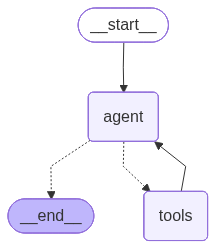

In [15]:
from IPython.display import Image, display

# 워크플로우 그래프를 시각화합니다
display(Image(ppt_workflow.get_graph().draw_mermaid_png()))

### 커스텀 워크플로우로 프레젠테이션 생성

커스텀 워크플로우를 사용하여 새 프레젠테이션을 생성합니다.

In [16]:
config4 = RunnableConfig(configurable={"thread_id": random_uuid()})

PPT_PATH4 = f"{WORKSPACE_DIR}/workflow_demo.pptx"

# client.session() 컨텍스트 안에서 MCP 연결을 유지하며 커스텀 워크플로우를 실행합니다
_client = MultiServerMCPClient(server_configs)
async with _client.session("powerpoint") as _session:
    tools = await load_mcp_tools(_session)
    ppt_workflow = create_powerpoint_workflow(tools)

    # 커스텀 워크플로우 실행
    response = await astream_graph(
        ppt_workflow,
        inputs={
            "messages": [
                (
                    "human",
                    f"다음 순서로 작업해주세요:\n"
                    f"1. '{PPT_PATH4}' 경로에 새 프레젠테이션을 생성합니다.\n"
                    f"2. 'StateGraph 워크플로우 구조'를 주제로 슬라이드를 3장 추가합니다.\n"
                    f"   각 슬라이드에 제목과 핵심 내용을 포함해주세요.\n"
                    f"3. 파일을 '{PPT_PATH4}'에 저장합니다.",
                )
            ]
        },
        config=config4,
    )


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네, 순서대로 작업을 진행하겠습니다! 먼저 새 프레젠테이션을 생성하겠습니다.

**Step 1: 새 프레젠테이션 생성**
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "presentation_id": "workflow_demo",
  "message": "Created new presentation with ID: workflow_demo",
  "slide_count": 0
}
🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
프레젠테이션이 생성되었습니다! 이제 3장의 슬라이드를 동시에 추가하겠습니다.

**Step 2: 슬라이드 3장 추가**
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "message": "Added slide 0 with layout 1",
  "slide_index": 0,
  "layout_name": "Title and Content"
}
🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "message": "Added slide 1 with layout 1",
  "slide_index": 1,
  "layout_name": "Title and Content"
}
🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - 

---

## 정리

이 튜토리얼에서 다룬 내용을 정리합니다:

1. **MCP PowerPoint 서버 연결**: `uvx`를 통해 `office-powerpoint-mcp-server`를 설치 없이 실행하고 `MultiServerMCPClient`로 연결
2. **프레젠테이션 생성 패턴**: `create_presentation` → 콘텐츠 추가 → `save_presentation`을 한 번의 에이전트 호출로 완결
3. **기존 파일 수정 패턴**: `open_presentation` → 수정 → `save_presentation`으로 별도 호출 간 상태 유지
4. **슬라이드 콘텐츠 관리**: `add_slide`, `manage_text`, `manage_bullets`로 구조화된 내용 삽입
5. **텍스트 서식 적용**: 폰트 크기, 굵기, 색상 등 세밀한 서식 제어
6. **표 삽입**: `add_table`로 비교표 등 구조화된 데이터 시각화
7. **복합 작업**: 여러 도구를 조합하여 완성형 5슬라이드 프레젠테이션 자동 생성
8. **커스텀 워크플로우**: `StateGraph`와 `ToolNode`를 활용한 세밀한 제어

### 주요 포인트

- `office-powerpoint-mcp-server`는 프레젠테이션 상태를 메모리에 유지하므로, 에이전트 호출마다 **열기(또는 생성) → 수정 → 저장** 패턴을 반드시 따릅니다
- `uvx`를 사용하면 별도 설치 없이 PyPI 패키지 기반 MCP 서버를 즉시 실행할 수 있습니다
- `create_agent`는 간편하게 에이전트를 생성하며, `StateGraph`는 더 세밀한 제어가 필요할 때 사용합니다
- 생성된 `.pptx` 파일은 `ppt_workspace/` 디렉토리에서 확인할 수 있습니다